# Automatic Exam Corrector — Analysis Notebook

1. **Dataset analysis** — image and cell-level statistics.
2. **All answer-box layouts** — bounding boxes across all 6 exams.
3. **Approach 1** — full-sheet image processing pipeline (fill-ratio / Otsu), one figure per stage.
4. **Approach 2** — cell-level ML pipeline (SIFT BoVW + SVM → CNN), one figure per stage.
5. **Per-exam comparison** — cells where ML is correct and fill-ratio fails.

Reference: Afifi & Hussain, *IJDAR* 22, 127–142 (2019).


## 0. Setup

In [ ]:
%matplotlib inline
import collections
import re
import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path("..").resolve()))

from src import capture, cell_extractor, perspective, preprocess, utils
from src.bubble_reader import read_marks_from_rects
from src.classifier import LABEL_CONFIRMED, LABEL_CROSSEDOUT, LABEL_EMPTY, load_classifier_local
from src.grader import grade
from src.grid_detector import draw_grid_contour, find_grid_canny
from src.registration import register, transform_rects
from src.visualizer import annotate_rects

ROOT        = Path("..").resolve()
DATASET_DIR = ROOT / "data" / "dataset" / "answer_sheets"
GT_PATH     = ROOT / "data" / "dataset" / "ground_truth" / "exams.mat"
MODELS_DIR  = ROOT / "models"
CONFIG      = utils.load_config(ROOT / "config" / "default.yaml")

LABEL_NAMES  = {LABEL_CONFIRMED: "Confirmed", LABEL_CROSSEDOUT: "Crossed-out", LABEL_EMPTY: "Empty"}
LABEL_COLORS = {LABEL_CONFIRMED: "#2ecc71", LABEL_CROSSEDOUT: "#e74c3c", LABEL_EMPTY: "#95a5a6"}

clf = load_classifier_local(MODELS_DIR)
print("Setup complete.")

## 1. Dataset Analysis

In [2]:
data_npz   = np.load(ROOT / "data" / "cell_dataset" / "cells.npz", allow_pickle=True)
labels_arr = data_npz["labels"]
img_names  = data_npz["image_names"]

exam_cell_cnt = collections.Counter(
    re.match(r"(exam\d+)", n).group(1)
    for n in img_names if re.match(r"(exam\d+)", n)
)
exam_img_cnt = collections.Counter(
    p.parent.name for p in sorted(DATASET_DIR.glob("**/*.png"))
)
exams = sorted(exam_img_cnt.keys())

print(f"{'Exam':<10} {'Images':>8}  {'Cells':>8}")
print("─" * 32)
for exam in exams:
    print(f"{exam:<10} {exam_img_cnt[exam]:>8,}  {exam_cell_cnt[exam]:>8,}")
print("─" * 32)
print(f"{'TOTAL':<10} {sum(exam_img_cnt.values()):>8,}  {len(labels_arr):>8,}")


Exam         Images     Cells
────────────────────────────────
exam0           120     1,569
exam1            99     2,970
exam2           103     3,090
exam3            60     1,800
exam4            62     1,860
exam5           371    21,518
────────────────────────────────
TOTAL           815    32,807


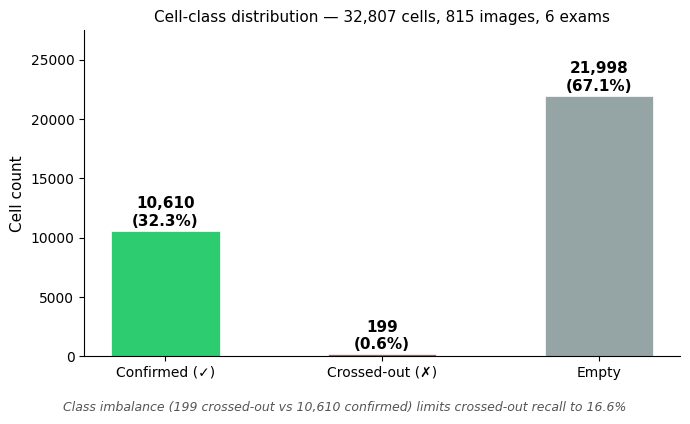

In [3]:
counts = {lbl: int(np.sum(labels_arr == lbl)) for lbl in [1, 2, 3]}
names  = {1: "Confirmed (✓)", 2: "Crossed-out (✗)", 3: "Empty"}
colors = [LABEL_COLORS[lbl] for lbl in [1, 2, 3]]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([names[k] for k in [1, 2, 3]], [counts[k] for k in [1, 2, 3]],
              color=colors, width=0.5, edgecolor="white", linewidth=0.5)
for bar, k in zip(bars, [1, 2, 3]):
    pct = counts[k] / len(labels_arr) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
            f"{counts[k]:,}\n({pct:.1f}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold")
ax.set_ylim(0, max(counts.values()) * 1.25)
ax.set_ylabel("Cell count", fontsize=11)
ax.set_title("Cell-class distribution — 32,807 cells, 815 images, 6 exams", fontsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.text(0.5, -0.04,
         "Class imbalance (199 crossed-out vs 10,610 confirmed) limits crossed-out recall to 16.6%",
         ha="center", fontsize=9, style="italic", color="#555")
plt.tight_layout(); plt.show()


## 2. All Answer-Box Layouts

One representative image per exam with all bounding boxes overlaid.
Colours encode option position: **green** = option A, **blue** = option B, **red** = option C.
Box coordinates come from pre-computed ground-truth in `exams.mat`.


In [ ]:
OPTION_COLORS = [(0, 180, 0), (30, 100, 220), (200, 40, 40)]

for exam in exams:
    img_path = sorted((DATASET_DIR / exam).glob("*.png"))[0]
    img      = capture.from_file(img_path)
    record   = utils.mat_load_record(GT_PATH, img_path.name)
    rects    = record["rects"]
    n_q      = record["n_questions"]
    n_opts   = max(len(r) for r in rects)

    viz = img.copy()
    for q_rects in rects:
        for c, (x, y, w, h) in enumerate(q_rects.astype(int)):
            color = OPTION_COLORS[c % len(OPTION_COLORS)]
            cv2.rectangle(viz, (x, y), (x + w, y + h), color, 2)

    h_px, w_px = viz.shape[:2]
    scale  = 6.0 / max(h_px, w_px)    # fit in ~6 inches
    fig_w, fig_h = max(4, w_px * scale), max(4, h_px * scale)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
    ax.set_title(
        f"{exam.capitalize()} — Answer Box Layout\n"
        f"{n_q} question(s) × up to {n_opts} option(s) per question  |  sample: {img_path.name}",
        fontsize=10
    )
    ax.axis("off")
    plt.tight_layout(); plt.show()

## 3. Approach 1 — Full-Sheet Image Processing Pipeline

The fill-ratio approach treats the **entire answer sheet** as a single image processing problem.
One figure per processing stage; each title names the CV technique and its academic reference.


In [ ]:
SAMPLE_NAME = "exam0_1_1.png"
img    = capture.from_file(DATASET_DIR / "exam0" / SAMPLE_NAME)
record = utils.mat_load_record(GT_PATH, SAMPLE_NAME)
rects  = record["rects"]
key    = record["key"]
n_opts = max(len(r) for r in rects)

gray    = preprocess.to_grayscale(img)
blurred = preprocess.apply_gaussian_blur(gray)
binary  = preprocess.otsu_threshold(blurred)

k_size  = int(CONFIG["bubble"].get("morph_open_kernel", 3))
morph_k = cv2.getStructuringElement(cv2.MORPH_RECT, (k_size, k_size))
opened  = cv2.morphologyEx(binary, cv2.MORPH_OPEN, morph_k)

marks_fr   = read_marks_from_rects(img, rects, CONFIG)
results_fr = grade(marks_fr, key, CONFIG)
annotated  = annotate_rects(img, rects, marks_fr, results_fr, CONFIG)

def _show(image, title, cmap=None, figsize=(6, 8)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("off")
    plt.tight_layout(); plt.show()

print(f"Sample: {SAMPLE_NAME}  |  {record['n_questions']} questions × {n_opts} options")

In [ ]:
_show(cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
      "Stage 1 — Image Acquisition\nInput: raw scanned exam sheet (BGR, OpenCV imread)")

In [ ]:
_show(gray, cmap="gray",
      title="Stage 2 — Grayscale Conversion\ncv2.cvtColor(img, cv2.COLOR_BGR2GRAY)\n"
            "Single-channel representation — reduces colour redundancy")

In [ ]:
_show(blurred, cmap="gray",
      title="Stage 3 — Gaussian Smoothing\ncv2.GaussianBlur(gray, (5, 5), σ=0)\n"
            "Suppresses high-frequency noise before thresholding\n"
            "[Gonzalez & Woods, Digital Image Processing §3.4]")

In [ ]:
_show(binary, cmap="gray",
      title="Stage 4 — Otsu's Global Thresholding\n"
            "cv2.threshold(blurred, 0, 255, THRESH_BINARY_INV + THRESH_OTSU)\n"
            "Minimises intra-class pixel variance — white = ink (foreground)\n"
            "[Otsu, IEEE Trans. Syst. Man Cybern. 9(1), 1979]")

In [ ]:
_show(opened, cmap="gray",
      title=f"Stage 5 — Morphological Opening  (kernel {k_size}×{k_size})\n"
            "cv2.morphologyEx(binary, cv2.MORPH_OPEN, rect_kernel)\n"
            "Erosion then dilation — removes small noise blobs while preserving mark shapes\n"
            "[Serra, Image Analysis and Mathematical Morphology, Academic Press 1982]")

In [ ]:
canny_img = canny_corners = None
for p in sorted(DATASET_DIR.glob("exam0/*.png")):
    _g = preprocess.to_grayscale(capture.from_file(p))
    _c = find_grid_canny(_g)
    if _c is not None:
        canny_img = capture.from_file(p)
        canny_name = p.name
        canny_corners = _c
        break

canny_gray = preprocess.to_grayscale(canny_img)
canny_blurred = cv2.GaussianBlur(canny_gray, (5, 5), 0)
edges = cv2.Canny(canny_blurred, 50, 150)

lines = cv2.HoughLinesP(edges, 1, np.pi/180, 80, minLineLength=150, maxLineGap=30)
hough_vis = cv2.cvtColor(canny_gray, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for ln in lines:
        x1, y1, x2, y2 = ln[0]
        cv2.line(hough_vis, (x1, y1), (x2, y2), (0, 200, 0), 2)

corners_vis = draw_grid_contour(canny_img, canny_corners)
for cx, cy in canny_corners.astype(int):
    cv2.circle(corners_vis, (cx, cy), 10, (0, 0, 255), -1)

warped_canny = perspective.warp(canny_img, canny_corners)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    "Stage 6 — Answer Box Identification (Approach 1)\n"
    "cv2.Canny → cv2.HoughLinesP → corner extraction → cv2.warpPerspective\n"
    "[Canny, IEEE TPAMI 8(6) 1986  ·  Duda & Hart, CACM 15(1) 1972  ·"
    "  Hartley & Zisserman, Multiple View Geometry, Cambridge UP 2003]",
    fontsize=10, y=1.02
)
for ax, (im, title) in zip(axes, [
    (edges,                              f"Canny edges\n(canny_lo=50, canny_hi=150)\n{canny_name}"),
    (cv2.cvtColor(hough_vis, cv2.COLOR_BGR2RGB), "HoughLinesP\n(threshold=80, minLen=150, maxGap=30)"),
    (cv2.cvtColor(corners_vis, cv2.COLOR_BGR2RGB), "Detected grid corners\n(blue dots = ordered corners)"),
    (cv2.cvtColor(warped_canny, cv2.COLOR_BGR2RGB), "Perspective-warped result\ncv2.warpPerspective"),
]):
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(title, fontsize=8, pad=4)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
def _compute_ratios(image, rects_list, ks):
    g  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    bl = cv2.GaussianBlur(g, (5, 5), 0)
    _, bi = cv2.threshold(bl, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mk = cv2.getStructuringElement(cv2.MORPH_RECT, (ks, ks))
    bi = cv2.morphologyEx(bi, cv2.MORPH_OPEN, mk)
    return np.array([
        [cv2.countNonZero(bi[y:y+h, x:x+w]) / (bi[y:y+h, x:x+w].size or 1)
         for x, y, w, h in qr.astype(int)]
        for qr in rects_list
    ])

ratios = _compute_ratios(img, rects, k_size)
opt_letters = list("ABC"[:ratios.shape[1]])

fig, ax = plt.subplots(figsize=(4, 6))
h_im = ax.imshow(ratios, cmap="YlOrRd", vmin=0, aspect="auto")
plt.colorbar(h_im, ax=ax, fraction=0.046, pad=0.04, label="fill ratio")
ax.set_xticks(range(ratios.shape[1])); ax.set_xticklabels(opt_letters, fontsize=10, fontweight="bold")
ax.set_yticks(range(len(rects)));   ax.set_yticklabels([f"Q{i+1}" for i in range(len(rects))], fontsize=9)
ax.tick_params(length=0)
ax.set_title(
    "Stage 7 — Fill-ratio Cell Classification\n"
    "For each cell: countNonZero(cell_roi) / cell_area\n"
    "Highest ratio per row = detected answer  (Approach 1 decision)",
    fontsize=10, pad=8
)
plt.tight_layout(); plt.show()

In [ ]:
_show(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
      "Stage 8 — Grading & Visualisation\n"
      "Detected mark vs. answer key → green circle = correct, red = wrong\n"
      f"Score: {results_fr['score']:.0f} / {results_fr['max_score']:.0f}")

## 4. Approach 2 — Cell-Level Image Processing & ML Classification

The ML approach (Afifi & Hussain, *IJDAR* 2019, Strategy B) processes each **individual cell** independently.
Box identification uses SIFT-based registration rather than uniform grid division.


In [ ]:
MODEL_REF_NAME = "exam0_1_1.png"
STUDENT_NAME   = "exam0_10_1.png"

model_ref_img  = capture.from_file(DATASET_DIR / "exam0" / MODEL_REF_NAME)
student_img_r  = capture.from_file(DATASET_DIR / "exam0" / STUDENT_NAME)
model_record   = utils.mat_load_record(GT_PATH, MODEL_REF_NAME)
model_rects    = model_record["rects"]

sift_reg  = cv2.SIFT_create()
gray_m    = cv2.cvtColor(model_ref_img, cv2.COLOR_BGR2GRAY)
gray_s    = cv2.cvtColor(student_img_r, cv2.COLOR_BGR2GRAY)
kp_m, des_m = sift_reg.detectAndCompute(gray_m, None)
kp_s, des_s = sift_reg.detectAndCompute(gray_s, None)

bf        = cv2.BFMatcher(cv2.NORM_L2)
raw_match = bf.knnMatch(des_s, des_m, k=2)
good      = [m for m, n in raw_match if m.distance < 0.75 * n.distance]

# Register student → model; invert to get model → student transform
M_reg = register(student_img_r, model_ref_img)
if M_reg is not None:
    M_inv = np.linalg.inv(M_reg)
    student_rects = transform_rects(model_rects, M_inv)
else:
    student_rects = model_rects
    print("Warning: registration failed, using original rects")

print(f"SIFT: {len(kp_m)} kp in model, {len(kp_s)} kp in student, {len(good)} good matches")

In [ ]:
kp_img_m = cv2.drawKeypoints(gray_m, kp_m, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
kp_img_s = cv2.drawKeypoints(gray_s, kp_s, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(
    "Box Identification (Approach 2) — Stage A: SIFT Keypoint Detection\n"
    "cv2.SIFT_create().detectAndCompute(gray, None)\n"
    "[Lowe, Distinctive Image Features from Scale-Invariant Keypoints, IJCV 60(2), 2004]",
    fontsize=10, y=1.01
)
for ax, (im, title) in zip(axes, [
    (cv2.cvtColor(kp_img_m, cv2.COLOR_BGR2RGB), f"Model reference: {MODEL_REF_NAME}\n{len(kp_m)} keypoints"),
    (cv2.cvtColor(kp_img_s, cv2.COLOR_BGR2RGB), f"Student sheet: {STUDENT_NAME}\n{len(kp_s)} keypoints"),
]):
    ax.imshow(im); ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
match_vis = cv2.drawMatchesKnn(
    gray_s, kp_s, gray_m, kp_m,
    [[m] for m in good[:40]], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    matchColor=(0, 220, 0), singlePointColor=(200, 0, 0),
)
fig, ax = plt.subplots(figsize=(20, 7))
ax.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
ax.set_title(
    f"Box Identification (Approach 2) — Stage B: BFMatcher + Lowe Ratio Test\n"
    f"cv2.BFMatcher(NORM_L2).knnMatch + ratio < 0.75  →  {len(good)} good matches (top 40 shown)\n"
    "[Lowe, IJCV 2004 §7.1 — ambiguous matches discarded when second-best is within 75% of best]",
    fontsize=10
)
ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
student_viz = student_img_r.copy()
for q_rects in student_rects:
    for c, (x, y, w, h) in enumerate(q_rects.astype(int)):
        cv2.rectangle(student_viz, (x, y), (x + w, y + h), OPTION_COLORS[c % 3], 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.suptitle(
    "Box Identification (Approach 2) — Stage C: RANSAC Homography → Box Transformation\n"
    "cv2.findHomography(pts_student, pts_model, RANSAC)  then  cv2.perspectiveTransform on model boxes\n"
    "[Hartley & Zisserman, Multiple View Geometry in Computer Vision, Cambridge UP 2003]",
    fontsize=10, y=1.01
)
axes[0].imshow(cv2.cvtColor(model_ref_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Model reference boxes\n{MODEL_REF_NAME}", fontsize=9)
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(student_viz, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Transformed boxes on student sheet\n{STUDENT_NAME}", fontsize=9)
axes[1].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
CELL_IMG_NAME = "exam0_1_1.png"
cell_img  = capture.from_file(DATASET_DIR / "exam0" / CELL_IMG_NAME)
cell_rec  = utils.mat_load_record(GT_PATH, CELL_IMG_NAME)
cell_rects = cell_rec["rects"]
answer_types = cell_rec["answer_types"]

picks = {}
cell_idx = 0
for q, q_rects in enumerate(cell_rects):
    for c, (x, y, w, h) in enumerate(q_rects.astype(int)):
        gt = answer_types[cell_idx]
        if gt not in picks:
            picks[gt] = (q, c, x, y, w, h)
        cell_idx += 1
    if len(picks) == 3:
        break

def _sift_hist(cell_64):
    _, desc = clf._sift.detectAndCompute(cell_64, None)
    hist = np.zeros(clf._k, dtype=np.float32)
    if desc is not None and len(desc) > 0:
        wids = clf._kmeans.predict(desc)
        for wid in wids: hist[wid] += 1
        if hist.sum() > 0: hist /= hist.sum()
    return hist

def _softmax(x):
    e = np.exp(x - x.max()); return e / e.sum()

GT_TYPES = [LABEL_CONFIRMED, LABEL_CROSSEDOUT, LABEL_EMPTY]
GT_LABEL_NAMES = {LABEL_CONFIRMED: "Confirmed (GT)", LABEL_CROSSEDOUT: "Crossed-out (GT)",
                  LABEL_EMPTY: "Empty (GT)"}

cell_data = {}
for gt in GT_TYPES:
    q, c, x, y, w, h = picks[gt]
    raw = cell_img[y:y+h, x:x+w]
    cell_64 = cell_extractor.extract_cells(cell_img, [np.array([[x,y,w,h]], dtype=float)])[0]
    sift_tmp = cv2.SIFT_create()
    kps, _   = sift_tmp.detectAndCompute(cell_64, None)
    kp_img   = cv2.drawKeypoints(cell_64, kps, None,
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    hist     = _sift_hist(cell_64)
    score    = float(clf._svm.decision_function([hist])[0])
    s1       = int(clf._svm.predict([hist])[0])
    cnn_p    = None
    if s1 == 1:
        blob  = cell_64.astype(np.float32)[np.newaxis, np.newaxis] / 255.0
        out   = clf._cnn.run(None, {clf._cnn_input: blob})[0][0]
        cnn_p = _softmax(out)
    final = clf.predict([cell_64])[0]
    cell_data[gt] = dict(q=q, c=c, raw=raw, cell_64=cell_64, kps=kps,
                         kp_img=kp_img, hist=hist, score=score, s1=s1,
                         cnn_p=cnn_p, final=final, gt=gt)

print("Cell data ready:", {LABEL_NAMES[k]: f"Q{v['q']+1} choice {chr(65+v['c'])}"
                            for k, v in cell_data.items()})

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Cell Stage 1 — Raw Cell Crop\n"
             "ROI extraction: img[y:y+h, x:x+w]  (BGR→RGB for display)",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    ax.imshow(cv2.cvtColor(d['raw'], cv2.COLOR_BGR2RGB))
    ax.set_title(GT_LABEL_NAMES[gt], fontsize=9, color=LABEL_COLORS[gt], fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Cell Stage 2 — Resize to 64×64 Grayscale\n"
             "cv2.resize(crop, (64,64), interpolation=cv2.INTER_AREA)"
             " — area-based downsampling preserves overall intensity",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    ax.imshow(d['cell_64'], cmap='gray')
    ax.set_title(GT_LABEL_NAMES[gt], fontsize=9, color=LABEL_COLORS[gt], fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle("Cell Stage 3 — SIFT Keypoint Detection\n"
             "cv2.SIFT_create().detectAndCompute(cell_64, None)"
             "  →  scale-invariant interest points\n"
             "[Lowe, Distinctive Image Features from Scale-Invariant"
             " Keypoints, IJCV 60(2), 2004]",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    ax.imshow(cv2.cvtColor(d['kp_img'], cv2.COLOR_BGR2RGB))
    ax.set_title(GT_LABEL_NAMES[gt] + f"\n{len(d['kps'])} keypoints",
                 fontsize=9, color=LABEL_COLORS[gt], fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Cell Stage 4 — Bag-of-Visual-Words Histogram\n"
             "SIFT descriptors → KMeans (k=100) cluster assignment"
             " → L1-normalised histogram\n"
             "[Sivic & Zisserman, Video Google, ICCV 2003"
             "  ·  vocabulary trained with sklearn.cluster.KMeans]",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    ax.bar(range(len(d['hist'])), d['hist'], width=1.0, color='#3498db', linewidth=0)
    ax.set_xlim(0, len(d['hist']))
    ax.set_title(GT_LABEL_NAMES[gt], fontsize=9, color=LABEL_COLORS[gt], fontweight='bold')
    ax.set_xlabel('visual word index', fontsize=7)
    ax.tick_params(labelsize=6)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Cell Stage 5 — Stage 1: RBF SVM  (filled vs empty)\n"
             "clf._svm.predict(BoVW_histogram)  →  0 = empty, 1 = filled\n"
             "[Vapnik, The Nature of Statistical Learning Theory,"
             " Springer 1998  ·  sklearn.svm.SVC with RBF kernel]",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    score = d['score']
    s1_lbl = 'Filled' if d['s1'] == 1 else 'Empty'
    bar_vals = [max(0., -score), max(0., score)]
    bar_clrs = ['#95a5a6', '#e67e22']
    ax.barh(['Empty', 'Filled'], bar_vals, color=bar_clrs, height=0.4)
    ax.set_xlim(0, max(abs(score), 0.01) + 0.05)
    ax.set_title(GT_LABEL_NAMES[gt] + f"\n→ {s1_lbl}  (score={score:+.2f})",
                 fontsize=9, color=LABEL_COLORS[gt], fontweight='bold')
    ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Cell Stage 6 — Stage 2: SmallCNN  (confirmed vs crossed-out)\n"
             "ONNX inference: (1,1,64,64) float32 → softmax"
             " → class 0=confirmed, 1=crossed-out\n"
             "[Afifi & Hussain, IJDAR 22 127-142 2019, Strategy B"
             "  ·  3x(Conv-BN-ReLU-Pool)->FC128->FC2]",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    if d['cnn_p'] is not None:
        ax.bar(['Confirmed', 'Crossed-out'], d['cnn_p'],
               color=['#2ecc71', '#e74c3c'], width=0.4)
        ax.set_ylim(0, 1.1)
        ax.tick_params(labelsize=7)
        winner = 'Confirmed' if np.argmax(d['cnn_p']) == 0 else 'Crossed-out'
        prob   = float(d['cnn_p'][np.argmax(d['cnn_p'])])
        ax.set_title(GT_LABEL_NAMES[gt] + f"\n-> {winner}  ({prob:.0%})",
                     fontsize=9, color=LABEL_COLORS[gt], fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'Skipped\n(empty cell)', ha='center', va='center',
                fontsize=10, color='#95a5a6', transform=ax.transAxes)
        ax.set_title(GT_LABEL_NAMES[gt], fontsize=9,
                     color=LABEL_COLORS[gt], fontweight='bold')
        ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Cell Stage 7 — Final Prediction\n"
             "Two-stage result: confirmed (1) / crossed-out (2) / empty (3)\n"
             "checkmark = matches ground truth  ·  X = mismatch",
             fontsize=10, y=1.01)
for ax, gt in zip(axes, GT_TYPES):
    d = cell_data[gt]
    name  = LABEL_NAMES[d['final']]
    color = LABEL_COLORS[d['final']]
    icon  = 'OK' if d['final'] == d['gt'] else 'WRONG'
    ax.text(0.5, 0.6, name, ha='center', va='center', fontsize=16,
            fontweight='bold', color=color, transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=color, linewidth=2))
    ax.text(0.5, 0.2, icon, ha='center', va='center', fontsize=13,
            color='#27ae60' if icon == 'OK' else '#c0392b',
            transform=ax.transAxes, fontweight='bold')
    ax.set_title(GT_LABEL_NAMES[gt], fontsize=9,
                 color=LABEL_COLORS[gt], fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Per-Exam Comparison — ML Correct, Fill-Ratio Wrong

For each exam, up to 3 cells where the ML classifier matches the ground truth and the fill-ratio baseline does not.
Full sheet shown with the problematic cell boxed in red.


In [26]:
def _fr_labels(image, rects_list):
    g  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    bl = cv2.GaussianBlur(g, (5, 5), 0)
    _, bi = cv2.threshold(bl, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    labels = []
    for q_rects in rects_list:
        ratios = []
        for x, y, w, h in q_rects.astype(int):
            cell = bi[y:y+h, x:x+w]
            ratios.append(cv2.countNonZero(cell) / cell.size if cell.size else 0.0)
        best = int(np.argmax(ratios))
        for i in range(len(ratios)):
            labels.append(LABEL_CONFIRMED if i == best else LABEL_EMPTY)
    return labels

def _error_type(fr, gt):
    if fr == LABEL_CONFIRMED and gt != LABEL_CONFIRMED: return "FP (false positive)"
    if fr == LABEL_EMPTY    and gt == LABEL_CONFIRMED:  return "FN (false negative)"
    if fr == LABEL_EMPTY    and gt == LABEL_CROSSEDOUT: return "FN (crossed-out missed)"
    return "misclassified"

def _find_candidates(exam_dir, max_cands=3):
    candidates, seen_types = [], set()
    for img_path in sorted(exam_dir.glob("*.png")):
        if len(candidates) >= max_cands: break
        try:
            image = capture.from_file(img_path)
            rec   = utils.mat_load_record(GT_PATH, img_path.name)
            rects = rec["rects"]; gt_lbs = rec["answer_types"]
        except Exception: continue
        cells  = cell_extractor.extract_cells(image, rects)
        ml_lbs = clf.predict(cells)
        fr_lbs = _fr_labels(image, rects)
        if len(fr_lbs) != len(gt_lbs) or len(ml_lbs) != len(gt_lbs): continue
        cell_idx = 0
        for q, q_rects in enumerate(rects):
            for c in range(len(q_rects)):
                gt = gt_lbs[cell_idx]; fr = fr_lbs[cell_idx]; ml = ml_lbs[cell_idx]
                if ml == gt and fr != gt and len(candidates) < max_cands:
                    err = _error_type(fr, gt)
                    if err in seen_types and len(candidates) < max_cands - 1:
                        cell_idx += 1; continue
                    seen_types.add(err)
                    candidates.append({"img_path": img_path, "img": image, "q": q, "c": c,
                                       "rect": q_rects[c].astype(int),
                                       "gt": gt, "fr": fr, "ml": ml, "err": err})
                cell_idx += 1
    return candidates



────────────────────────────────────────────────────────────
  EXAM0 — 3 candidate(s)
────────────────────────────────────────────────────────────


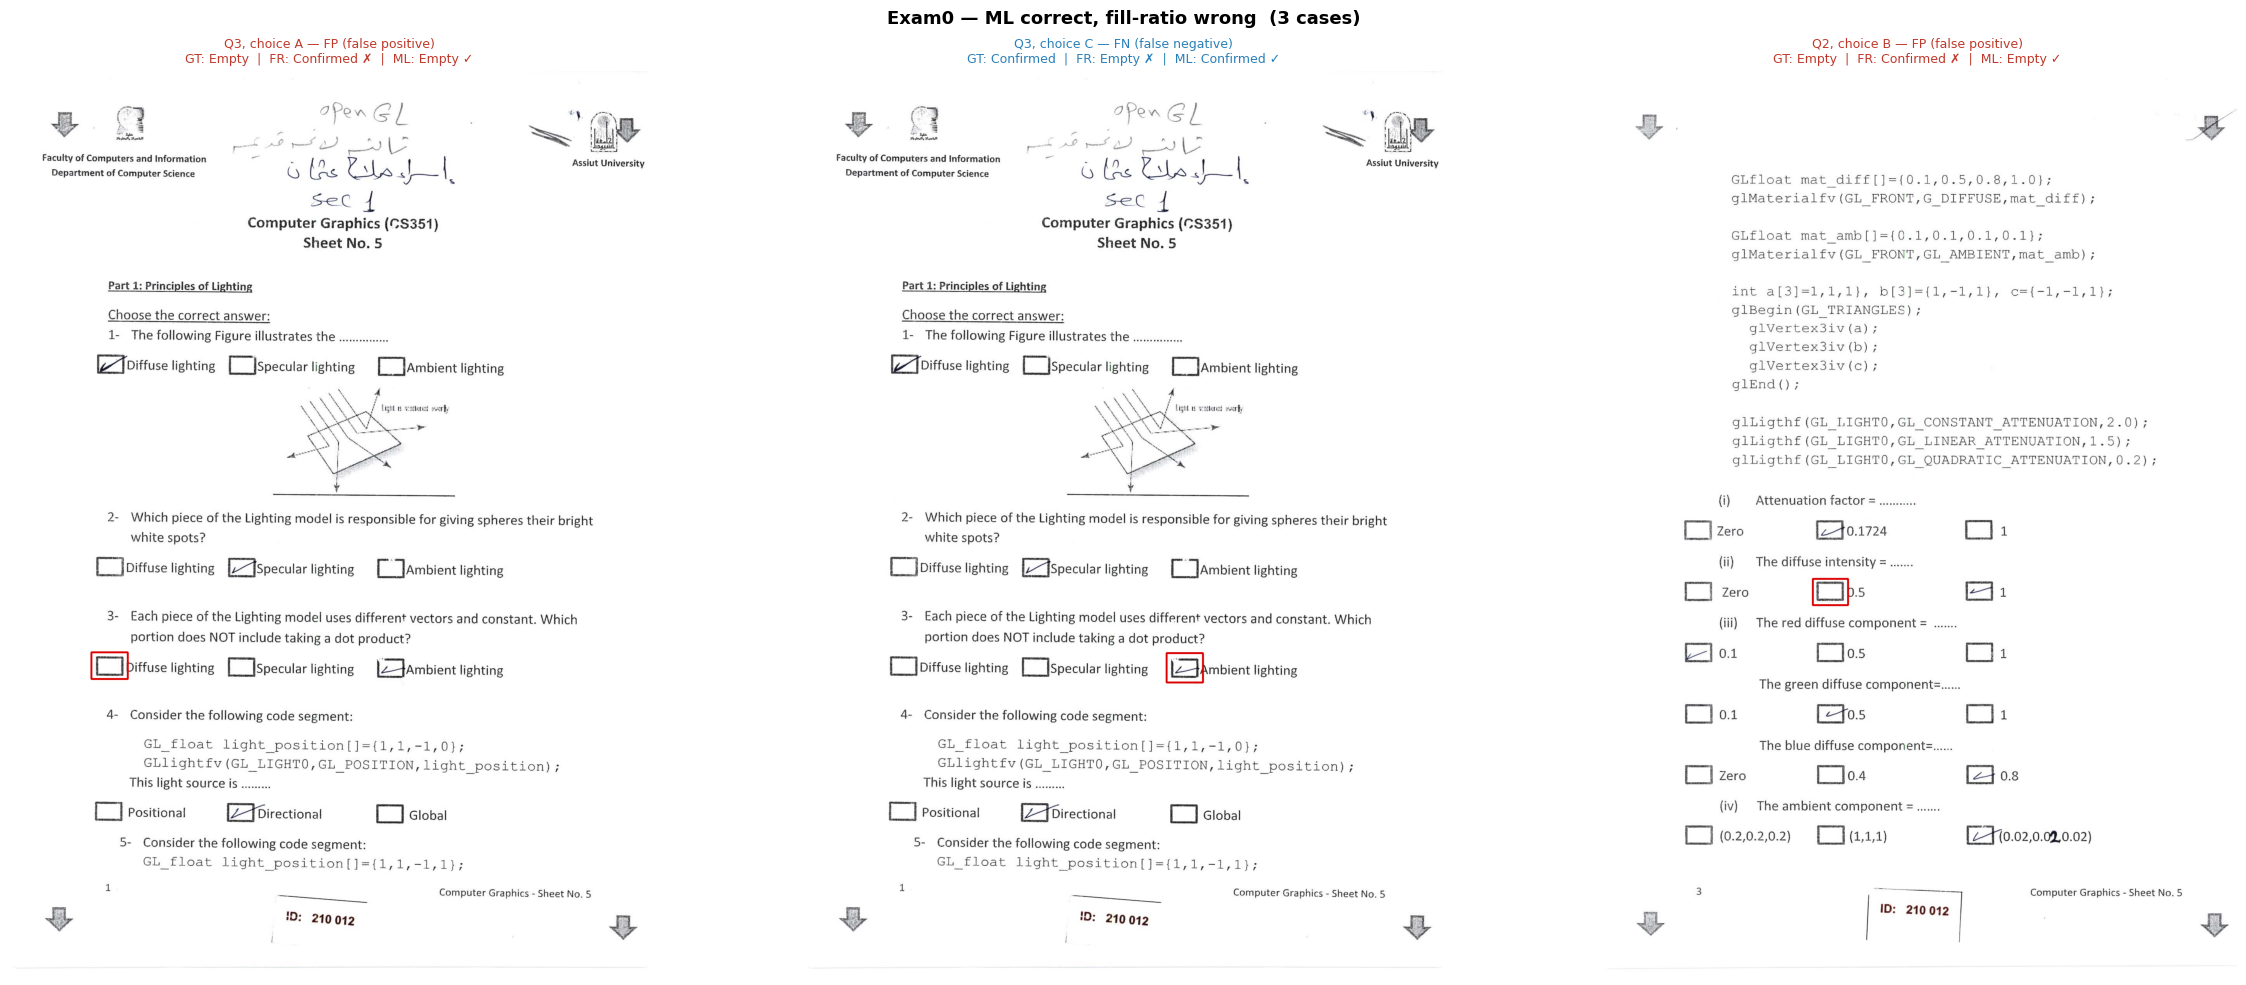


────────────────────────────────────────────────────────────
  EXAM1 — 3 candidate(s)
────────────────────────────────────────────────────────────


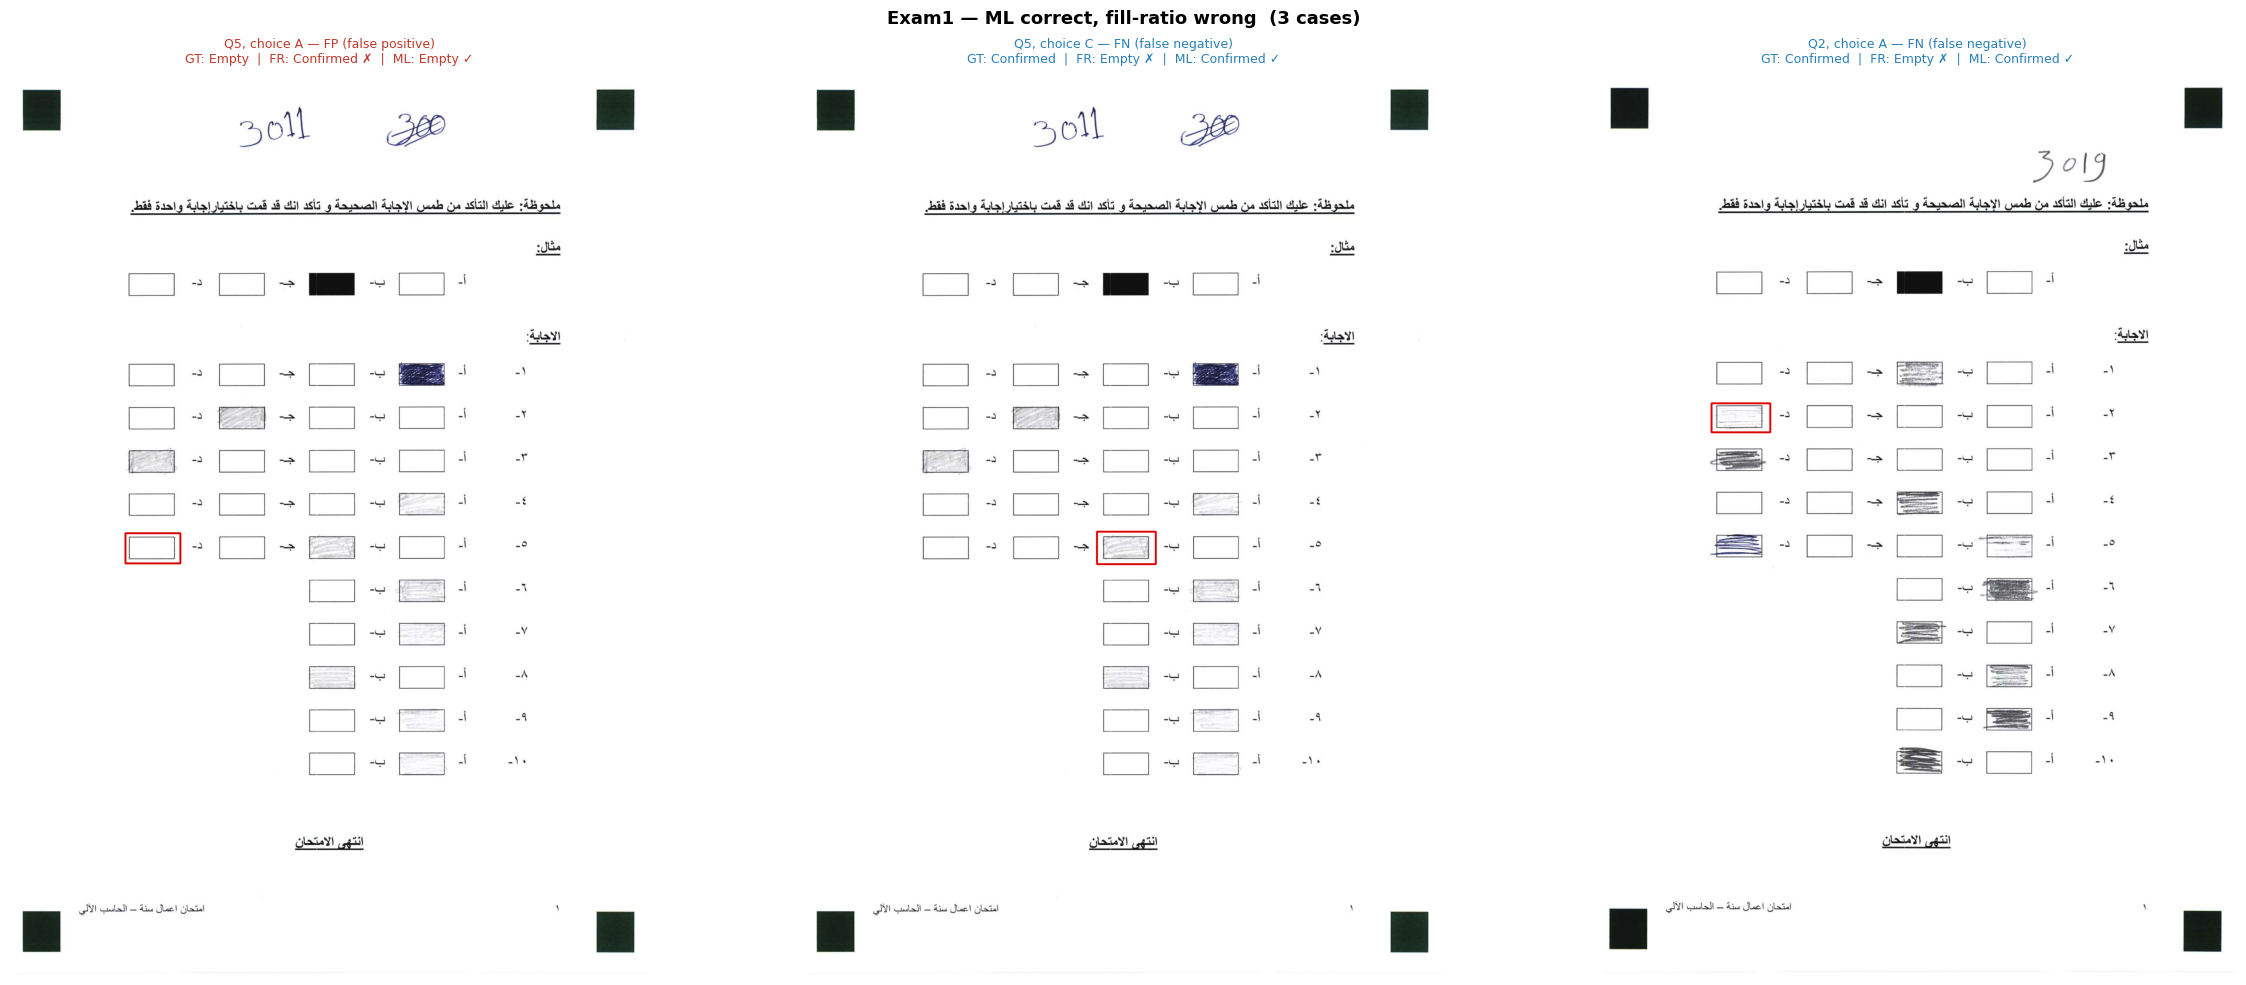


────────────────────────────────────────────────────────────
  EXAM2 — 3 candidate(s)
────────────────────────────────────────────────────────────


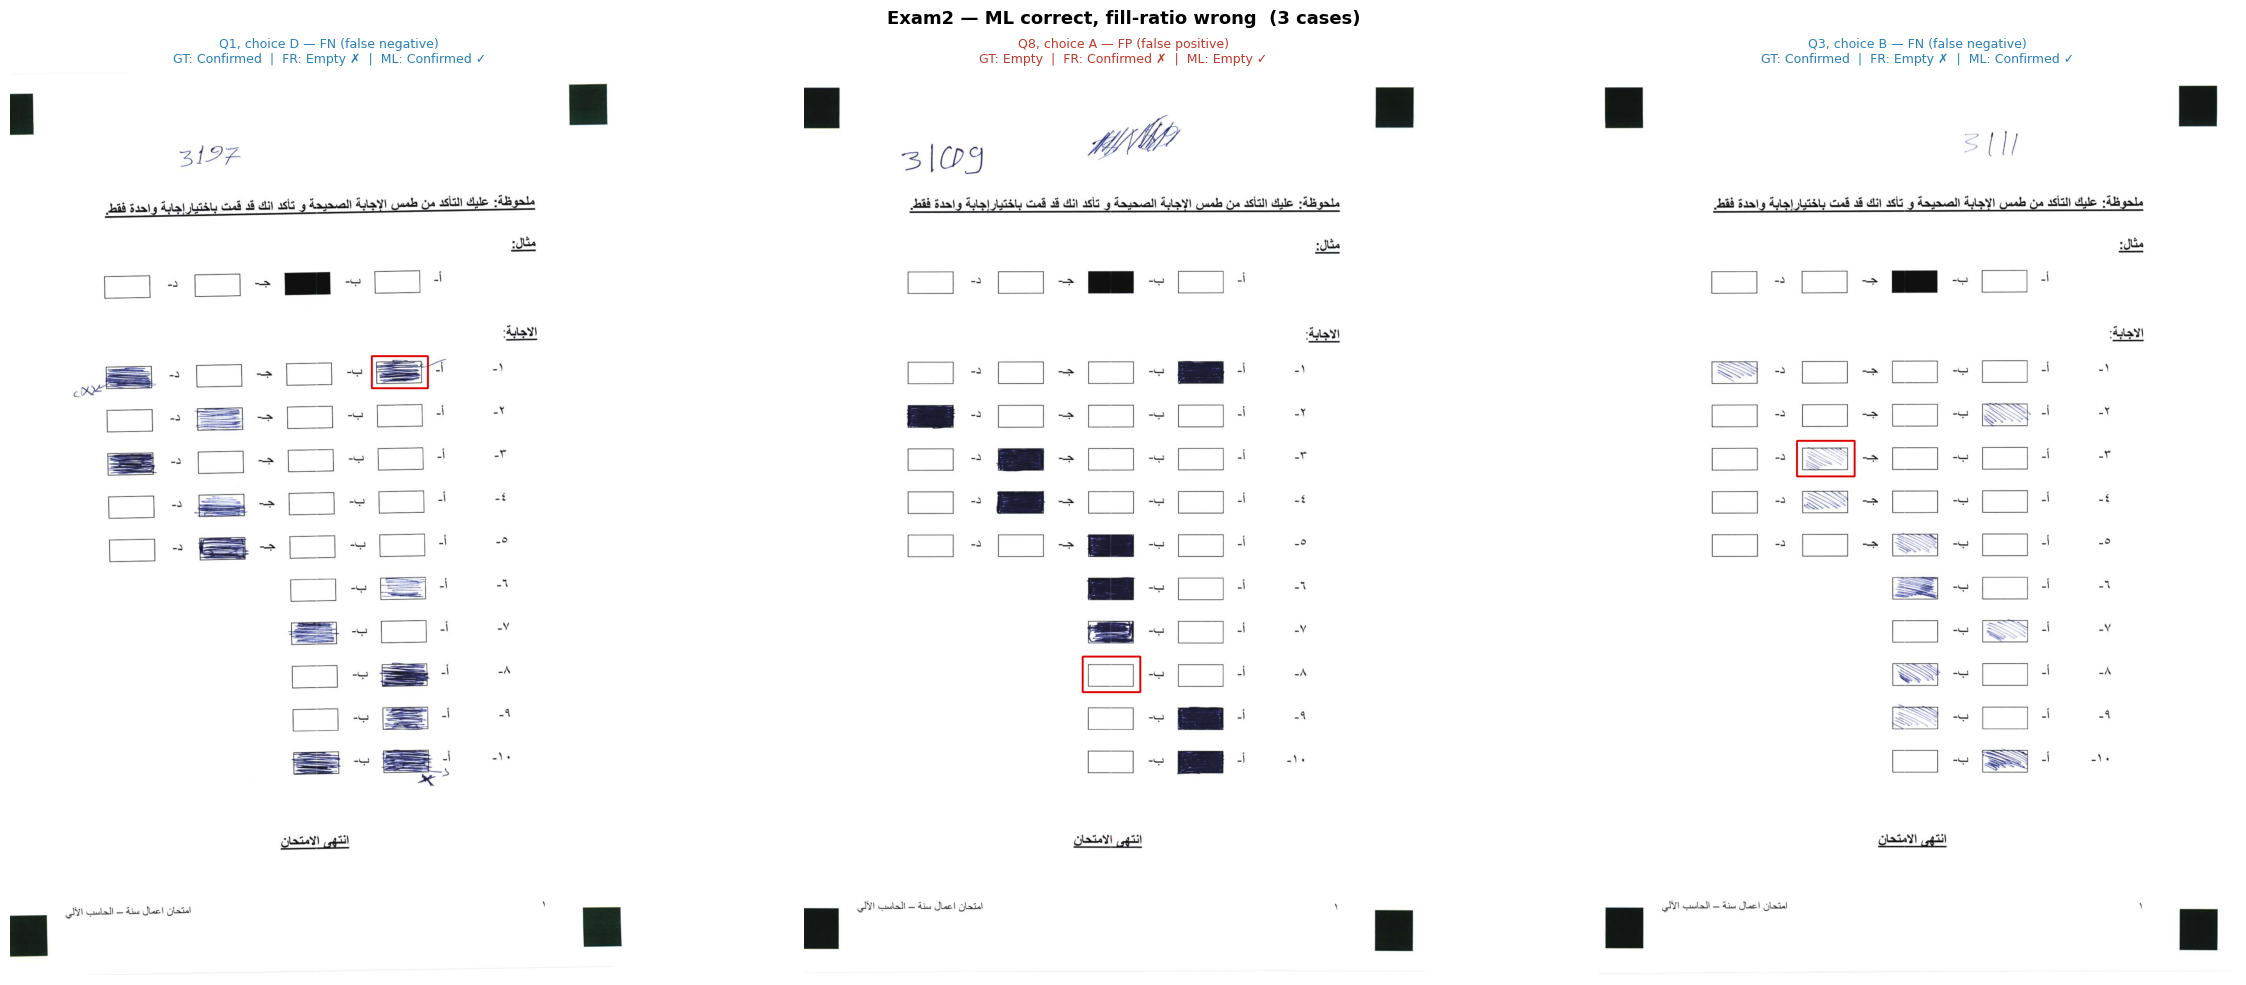


────────────────────────────────────────────────────────────
  EXAM3 — 3 candidate(s)
────────────────────────────────────────────────────────────


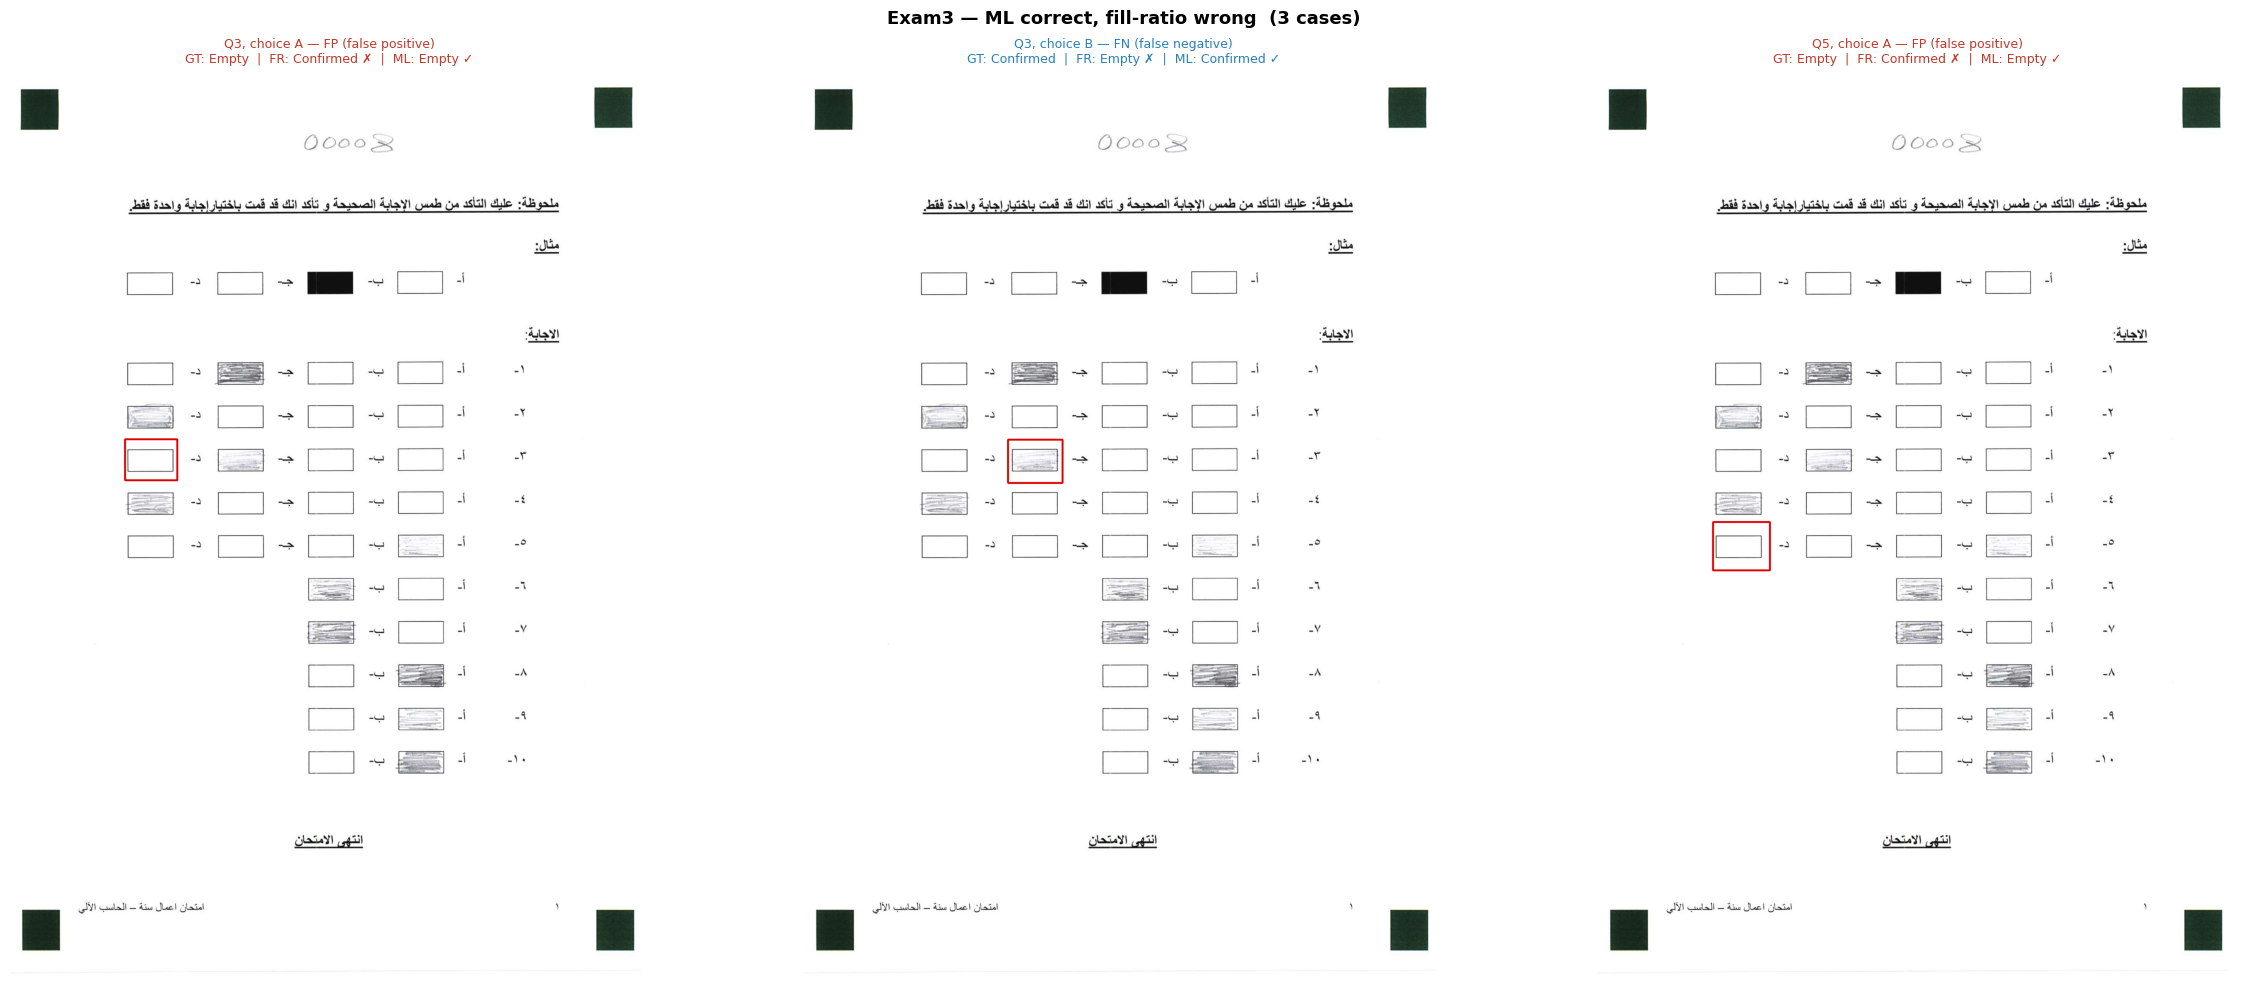


────────────────────────────────────────────────────────────
  EXAM4 — 3 candidate(s)
────────────────────────────────────────────────────────────


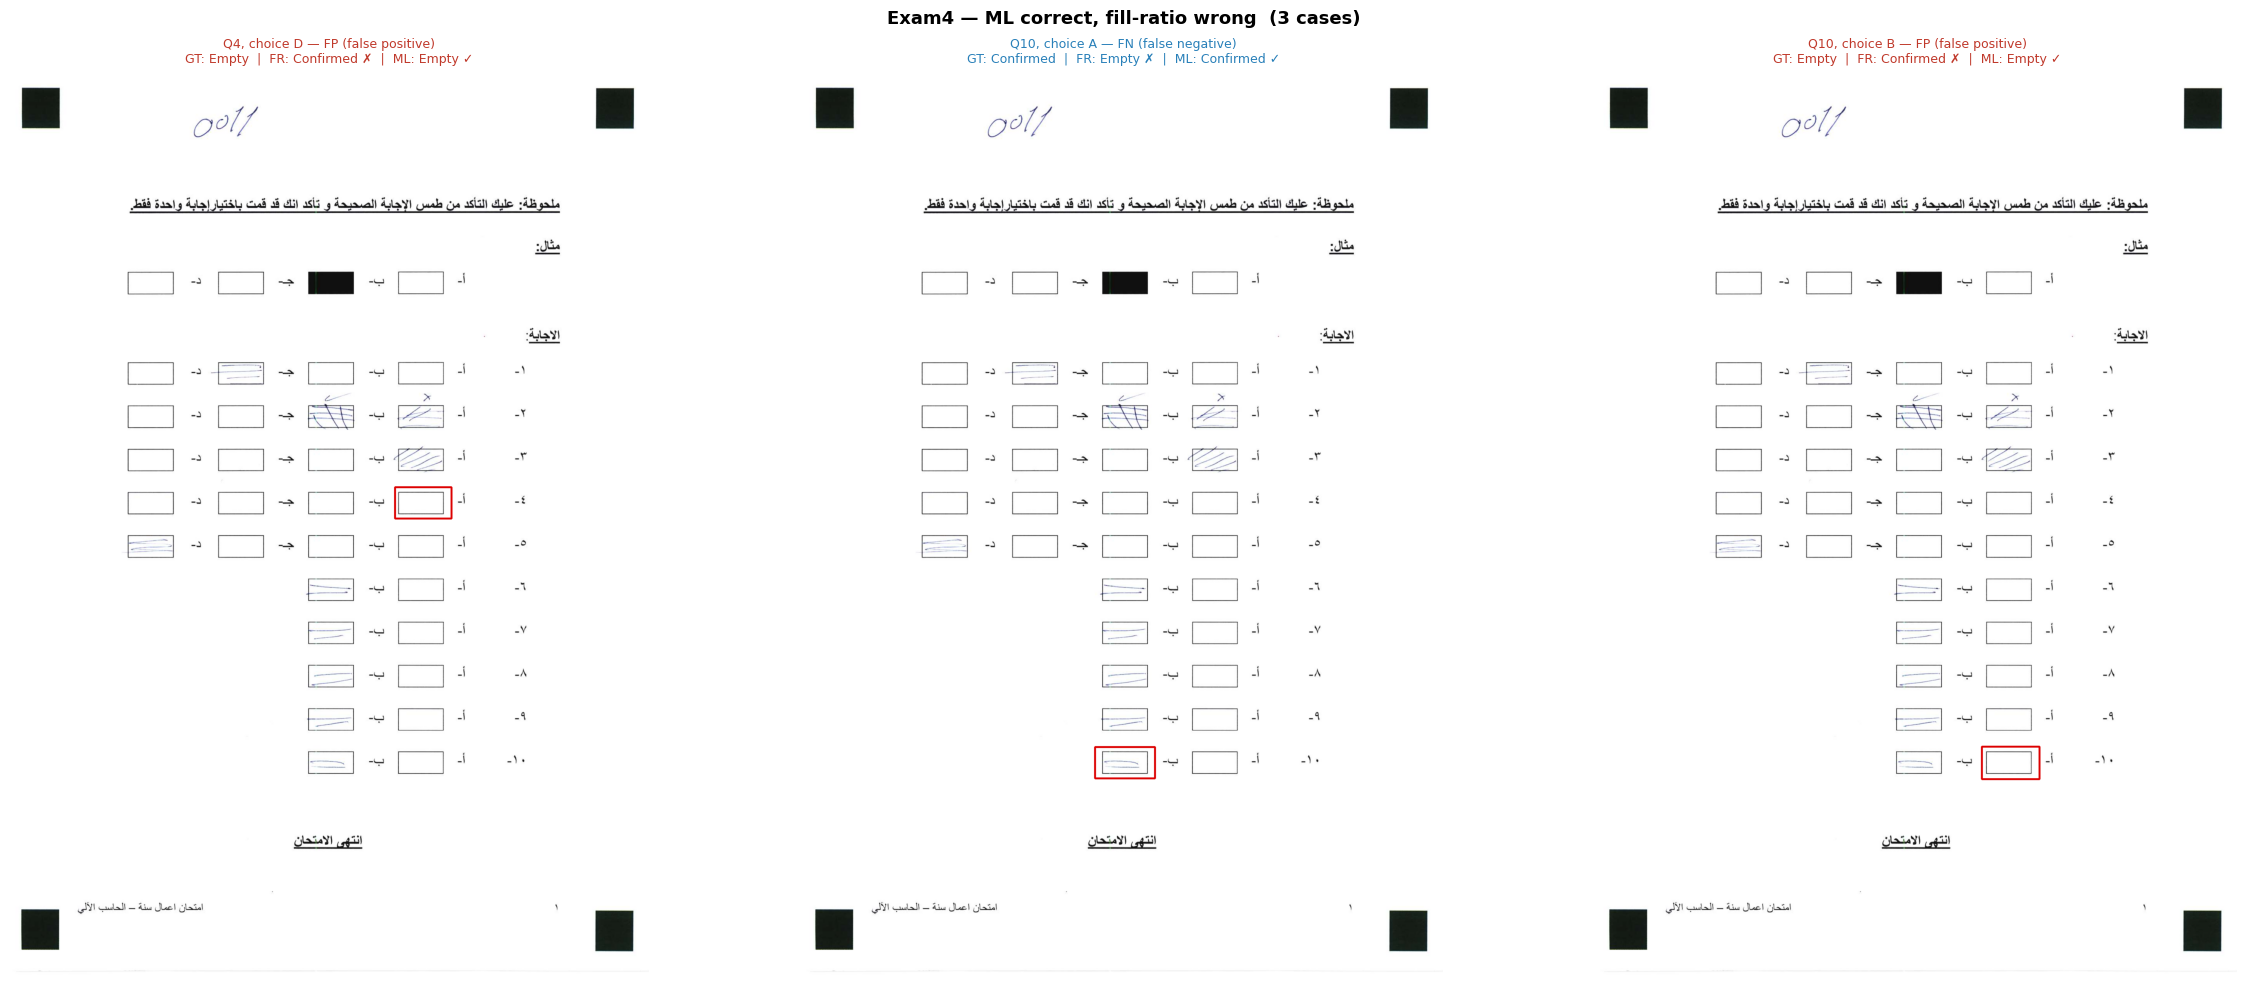


────────────────────────────────────────────────────────────
  EXAM5 — 3 candidate(s)
────────────────────────────────────────────────────────────


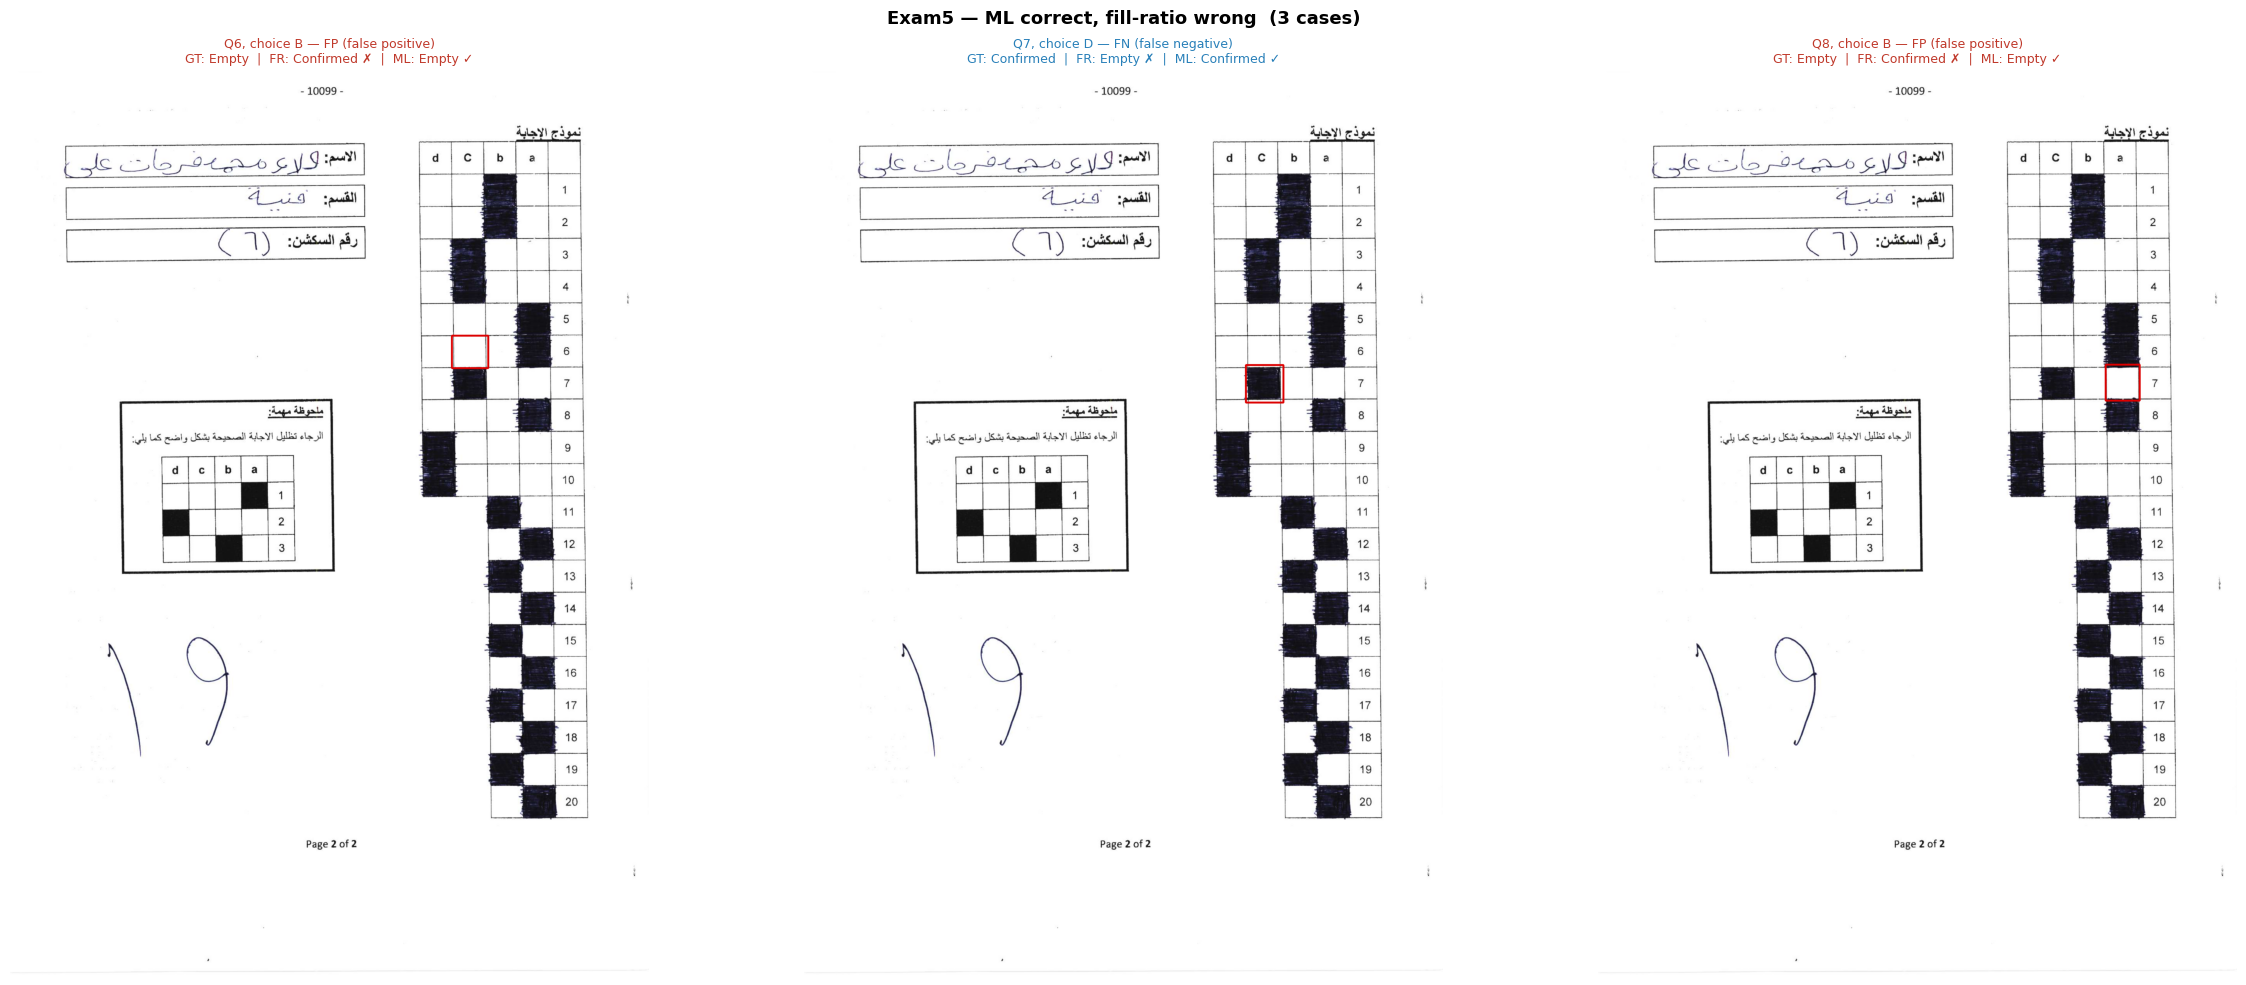

In [27]:
for exam in exams:
    candidates = _find_candidates(DATASET_DIR / exam, max_cands=3)
    print(f"\n{'─'*60}\n  {exam.upper()} — {len(candidates)} candidate(s)\n{'─'*60}")
    if not candidates:
        print("  No candidates found."); continue
    n   = len(candidates)
    fig, axes = plt.subplots(1, n, figsize=(8*n, 10), squeeze=False)
    fig.suptitle(f"{exam.capitalize()} — ML correct, fill-ratio wrong  ({n} case{'s' if n>1 else ''})",
                 fontsize=13, fontweight="bold")
    for ax, cand in zip(axes[0], candidates):
        x, y, w, h = cand["rect"]
        viz = cand["img"].copy()
        cv2.rectangle(viz, (max(0,x-4), max(0,y-4)), (x+w+4, y+h+4), (0,0,220), 3)
        ax.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
        title = (f"Q{cand['q']+1}, choice {chr(65+cand['c'])} — {cand['err']}\n"
                 f"GT: {LABEL_NAMES[cand['gt']]}  |  FR: {LABEL_NAMES[cand['fr']]} ✗  |  ML: {LABEL_NAMES[cand['ml']]} ✓")
        ax.set_title(title, fontsize=9, color="#c0392b" if "FP" in cand["err"] else "#2980b9", pad=6)
        ax.set_xlabel(cand["img_path"].name, fontsize=8, color="#555"); ax.axis("off")
    plt.tight_layout(); plt.show()


---
*Generated by `notebooks/_gen_notebook.py`.  Reference: Afifi & Hussain, IJDAR 22, 127–142 (2019).*